## Cell 1 — Install

In [83]:
!pip install easyocr transformers sentencepiece -q

## Cell 2 — Imports

In [84]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import easyocr
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Cell 3 — Load EasyOCR Readers

In [85]:
reader_hi = easyocr.Reader(['hi', 'en'], gpu=True)
reader_bn = easyocr.Reader(['bn', 'en'], gpu=True)
print("EasyOCR readers ready.")

EasyOCR readers ready.


## Cell 4 — Load Translation Models

In [86]:
hi_tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-hi-en")
hi_model     = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-hi-en")

bn_tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-bn-en")
bn_model     = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-bn-en")

print("Translation models ready.")

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Translation models ready.


## Cell 5 — CRNN: Define, Train, Save Weights

In [87]:
# ── Dataset paths ─────────────────────────────────────────────────────────────
deva_base   = "/kaggle/input/datasets/ashokpant/devanagari-character-dataset/nhcd/nhcd"
bangla_base = "/kaggle/input/datasets/asefjamilajwad2/banglalekha-isolated/BanglaLekha-Isolated/Images"

# ── Load balanced samples ─────────────────────────────────────────────────────
def get_balanced_samples(base_path, ext, samples_per_class=50):
    class_images = defaultdict(list)
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith(ext):
                class_name = os.path.basename(root)
                class_images[class_name].append(os.path.join(root, file))
    selected = []
    for class_name, images in class_images.items():
        random.shuffle(images)
        for img_path in images[:samples_per_class]:
            selected.append((img_path, class_name))
    return selected

hindi_data   = get_balanced_samples(deva_base,   '.jpg', 50)
bengali_data = get_balanced_samples(bangla_base, '.png', 50)
all_data     = hindi_data + bengali_data

all_labels  = sorted(set([label for _, label in all_data]))
label2idx   = {label: idx for idx, label in enumerate(all_labels)}
idx2label   = {idx: label for label, idx in label2idx.items()}
num_classes = len(all_labels)

hindi_labels   = set([label for _, label in hindi_data])
bengali_labels = set([label for _, label in bengali_data])

print(f"Hindi samples: {len(hindi_data)} | Bengali samples: {len(bengali_data)}")
print(f"Total: {len(all_data)} | Classes: {num_classes}")

# ── Transform ─────────────────────────────────────────────────────────────────
crnn_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((32, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ── Dataset class ─────────────────────────────────────────────────────────────
class IndicDataset(Dataset):
    def __init__(self, data, transform):
        self.data      = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        return img, label2idx[label]

dataset    = IndicDataset(all_data, crnn_transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Batches per epoch: {len(dataloader)}")

# ── CRNN Architecture ─────────────────────────────────────────────────────────
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
        )
        self.rnn = nn.LSTM(128 * 4, 256, batch_first=True, bidirectional=True)
        self.fc  = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        b, c, h, w = x.size()
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(b, w, c * h)
        x, _ = self.rnn(x)
        x = self.fc(x[:, -1, :])
        return x

# ── Train ─────────────────────────────────────────────────────────────────────
crnn_model = CRNN(num_classes).to(device)
optimizer  = optim.Adam(crnn_model.parameters(), lr=0.001)
criterion  = nn.CrossEntropyLoss()

for epoch in range(10):
    crnn_model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in dataloader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = crnn_model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    acc = 100. * correct / total
    print(f"Epoch {epoch+1}/10 | Loss: {total_loss/len(dataloader):.4f} | Accuracy: {acc:.2f}%")

torch.save(crnn_model.state_dict(), '/kaggle/working/indic_crnn_finetuned.pth')
print("\n✅ Weights saved to /kaggle/working/indic_crnn_finetuned.pth")

Hindi samples: 1850 | Bengali samples: 4200
Total: 6050 | Classes: 94
Batches per epoch: 190
Epoch 1/10 | Loss: 4.0203 | Accuracy: 5.34%
Epoch 2/10 | Loss: 3.0536 | Accuracy: 19.69%
Epoch 3/10 | Loss: 2.3840 | Accuracy: 35.19%
Epoch 4/10 | Loss: 1.8631 | Accuracy: 48.91%
Epoch 5/10 | Loss: 1.4385 | Accuracy: 60.98%
Epoch 6/10 | Loss: 1.0960 | Accuracy: 70.81%
Epoch 7/10 | Loss: 0.8457 | Accuracy: 77.65%
Epoch 8/10 | Loss: 0.5724 | Accuracy: 86.08%
Epoch 9/10 | Loss: 0.3914 | Accuracy: 91.55%
Epoch 10/10 | Loss: 0.2398 | Accuracy: 96.08%

✅ Weights saved to /kaggle/working/indic_crnn_finetuned.pth


## Cell 6 — Load CRNN Weights + Script Validator

In [89]:
# Load saved weights into eval mode
crnn_model.load_state_dict(
    torch.load('/kaggle/working/indic_crnn_finetuned.pth', map_location=device)
)
crnn_model.eval()
print(f"CRNN loaded on {device}")

# Script label mapper
def idx_to_script(idx):
    label = idx2label[idx]
    if label in bengali_labels:
        return 'bn'
    return 'hi'

# CRNN-based script validator for low-confidence crops
def crnn_detect_script(crop_bgr):
    """
    Splits a text crop into character-sized patches,
    runs each through CRNN, majority vote decides script.
    Returns: 'hi' or 'bn'
    """
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    patch_w     = max(32, h)
    num_patches = max(1, w // patch_w)
    votes = {'hi': 0, 'bn': 0}

    for i in range(num_patches):
        x_start = i * patch_w
        x_end   = min(x_start + patch_w, w)
        patch   = gray[:, x_start:x_end]
        if patch.shape[1] < 8:
            continue
        pil_patch = Image.fromarray(patch).convert('RGB')
        tensor    = crnn_transform(pil_patch).unsqueeze(0).to(device)
        with torch.no_grad():
            output   = crnn_model(tensor)
            pred_idx = output.argmax(dim=1).item()
        votes[idx_to_script(pred_idx)] += 1

    return 'bn' if votes['bn'] >= votes['hi'] else 'hi'

print("CRNN script validator ready.")

CRNN loaded on cuda
CRNN script validator ready.


## Cell 7 — Helper Functions

In [90]:
CONF_THRESHOLD  = 0.50
CONF_CLOSE_BAND = 0.10

# Unicode script detection
def detect_script(text):
    hi_count = sum(1 for ch in text if '\u0900' <= ch <= '\u097F')
    bn_count = sum(1 for ch in text if '\u0980' <= ch <= '\u09FF')
    if bn_count > hi_count:
        return 'bn'
    elif hi_count > 0:
        return 'hi'
    return 'en'

# Translation
def translate_hi(text):
    if not text.strip(): return ""
    inputs = hi_tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        out = hi_model.generate(**inputs, max_new_tokens=128)
    return hi_tokenizer.decode(out[0], skip_special_tokens=True)

def translate_bn(text):
    if not text.strip(): return ""
    inputs = bn_tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        out = bn_model.generate(**inputs, max_new_tokens=128)
    return bn_tokenizer.decode(out[0], skip_special_tokens=True)

# Confidence-aware OCR selector
def select_best_ocr(hi_res, bn_res):
    hi_text = hi_res[0][1] if hi_res else ""
    hi_conf = hi_res[0][2] if hi_res else 0.0
    bn_text = bn_res[0][1] if bn_res else ""
    bn_conf = bn_res[0][2] if bn_res else 0.0

    if not hi_text and not bn_text: return "", "EN", 0.0
    if not hi_text: return bn_text, "BN", bn_conf
    if not bn_text: return hi_text, "HI", hi_conf

    if abs(hi_conf - bn_conf) >= CONF_CLOSE_BAND:
        return (bn_text, "BN", bn_conf) if bn_conf > hi_conf else (hi_text, "HI", hi_conf)

    # Close confidence — use Unicode tiebreaker
    if detect_script(bn_text) == 'bn': return bn_text, "BN", bn_conf
    if detect_script(hi_text) == 'hi': return hi_text, "HI", hi_conf
    return (bn_text, "EN", bn_conf) if bn_conf >= hi_conf else (hi_text, "EN", hi_conf)

print("Helper functions ready.")

Helper functions ready.


## Cell 8 — Main Pipeline

In [91]:
def draw_boxes(image_path):
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")
    annotated = image_bgr.copy()

    # Step 1 — Detect regions
    base_reader = easyocr.Reader(['en'], gpu=True)
    detections  = base_reader.readtext(image_bgr, detail=1)
    print(f"Detected {len(detections)} text regions.")

    results_log = []

    for idx, (bbox, _, _) in enumerate(detections):
        xs = [int(p[0]) for p in bbox]
        ys = [int(p[1]) for p in bbox]
        x_min = max(0, min(xs));  x_max = min(image_bgr.shape[1], max(xs))
        y_min = max(0, min(ys));  y_max = min(image_bgr.shape[0], max(ys))
        if x_max <= x_min or y_max <= y_min: continue

        crop = image_bgr[y_min:y_max, x_min:x_max]

        # Step 2 — Run both readers
        hi_res = reader_hi.readtext(crop, detail=1)
        bn_res = reader_bn.readtext(crop, detail=1)

        # Step 3 — Select best
        text, lang, conf = select_best_ocr(hi_res, bn_res)
        if not text.strip(): continue

        crnn_used = False

        # Step 4 — High confidence: translate directly
        if conf >= CONF_THRESHOLD:
            if lang == "HI":
                translated = translate_hi(text)
                box_color  = (0, 200, 0)       # GREEN
            elif lang == "BN":
                translated = translate_bn(text)
                box_color  = (255, 100, 0)     # BLUE
            else:
                translated = text
                box_color  = (200, 200, 0)     # CYAN
            label = f"[{lang}] {translated[:30]}  ({conf:.2f})"

        # Step 5 — Low confidence: CRNN validates script → retry
        else:
            crnn_used   = True
            crnn_script = crnn_detect_script(crop)

            if crnn_script == 'bn':
                retry_res  = reader_bn.readtext(crop, detail=1)
                retry_lang = "BN"
            else:
                retry_res  = reader_hi.readtext(crop, detail=1)
                retry_lang = "HI"

            retry_text = retry_res[0][1] if retry_res else text
            retry_conf = retry_res[0][2] if retry_res else conf

            if retry_conf >= CONF_THRESHOLD:
                text, lang, conf = retry_text, retry_lang, retry_conf
                if lang == "BN":
                    translated = translate_bn(text)
                    box_color  = (255, 165, 0)   # ORANGE = BN recovered by CRNN
                else:
                    translated = translate_hi(text)
                    box_color  = (0, 165, 255)   # YELLOW = HI recovered by CRNN
                label = f"[{lang}+CRNN] {translated[:28]}  ({conf:.2f})"
            else:
                translated = None
                text, lang, conf = retry_text, retry_lang, retry_conf
                box_color  = (0, 0, 220)         # RED = still low
                label      = f"[{lang}+CRNN] LOW ({conf:.2f}): {text[:15]}"

        results_log.append({
            "region": idx, "lang": lang, "conf": round(conf, 3),
            "crnn_used": crnn_used, "ocr": text, "translation": translated
        })

        # Draw box
        pts = np.array([(int(p[0]), int(p[1])) for p in bbox], dtype=np.int32)
        cv2.polylines(annotated, [pts], isClosed=True, color=box_color, thickness=2)

        label_x = max(0, x_min)
        label_y = max(15, y_min - 5)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.50, 1)
        cv2.rectangle(annotated, (label_x, label_y-th-4), (label_x+tw, label_y+2), box_color, -1)
        cv2.putText(annotated, label, (label_x, label_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255,255,255), 1, cv2.LINE_AA)

    # Display
    plt.figure(figsize=(14, 10))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Multilingual OCR Pipeline  |  {os.path.basename(image_path)}",
              fontsize=13, fontweight='bold')
    legend = [
        mpatches.Patch(color='#00C800', label='Hindi  — high conf → translated'),
        mpatches.Patch(color='#FF6400', label='Bengali — high conf → translated'),
        mpatches.Patch(color='#00A5FF', label='Hindi  — recovered by CRNN → translated'),
        mpatches.Patch(color='#FFA500', label='Bengali — recovered by CRNN → translated'),
        mpatches.Patch(color='#C8C800', label='English — no translation'),
        mpatches.Patch(color='#0000DC', label='Low conf — CRNN used, still failed → skipped'),
    ]
    plt.legend(handles=legend, loc='upper right', fontsize=8, framealpha=0.9, fancybox=True)
    plt.tight_layout()
    plt.show()

    # Results table
    print(f"\n{'─'*80}")
    print(f"{'#':>3}  {'Lang':>8}  {'Conf':>5}  {'CRNN':>4}  {'OCR Text':<22}  {'Translation'}")
    print(f"{'─'*80}")
    for r in results_log:
        crnn_flag = "YES" if r['crnn_used'] else "no"
        trans_str = r['translation'] if r['translation'] else "— (low confidence)"
        print(f"{r['region']:>3}  {r['lang']:>8}  {r['conf']:>5.2f}  "
              f"{crnn_flag:>4}  {r['ocr'][:22]:<22}  {trans_str[:35]}")
    print(f"{'─'*80}")
    crnn_count = sum(1 for r in results_log if r['crnn_used'])
    print(f"Total: {len(results_log)} regions | CRNN invoked on: {crnn_count} low-confidence regions")

print("draw_boxes() defined.")

draw_boxes() defined.


## Cell 9 — Run on Image

Detected 4 text regions.


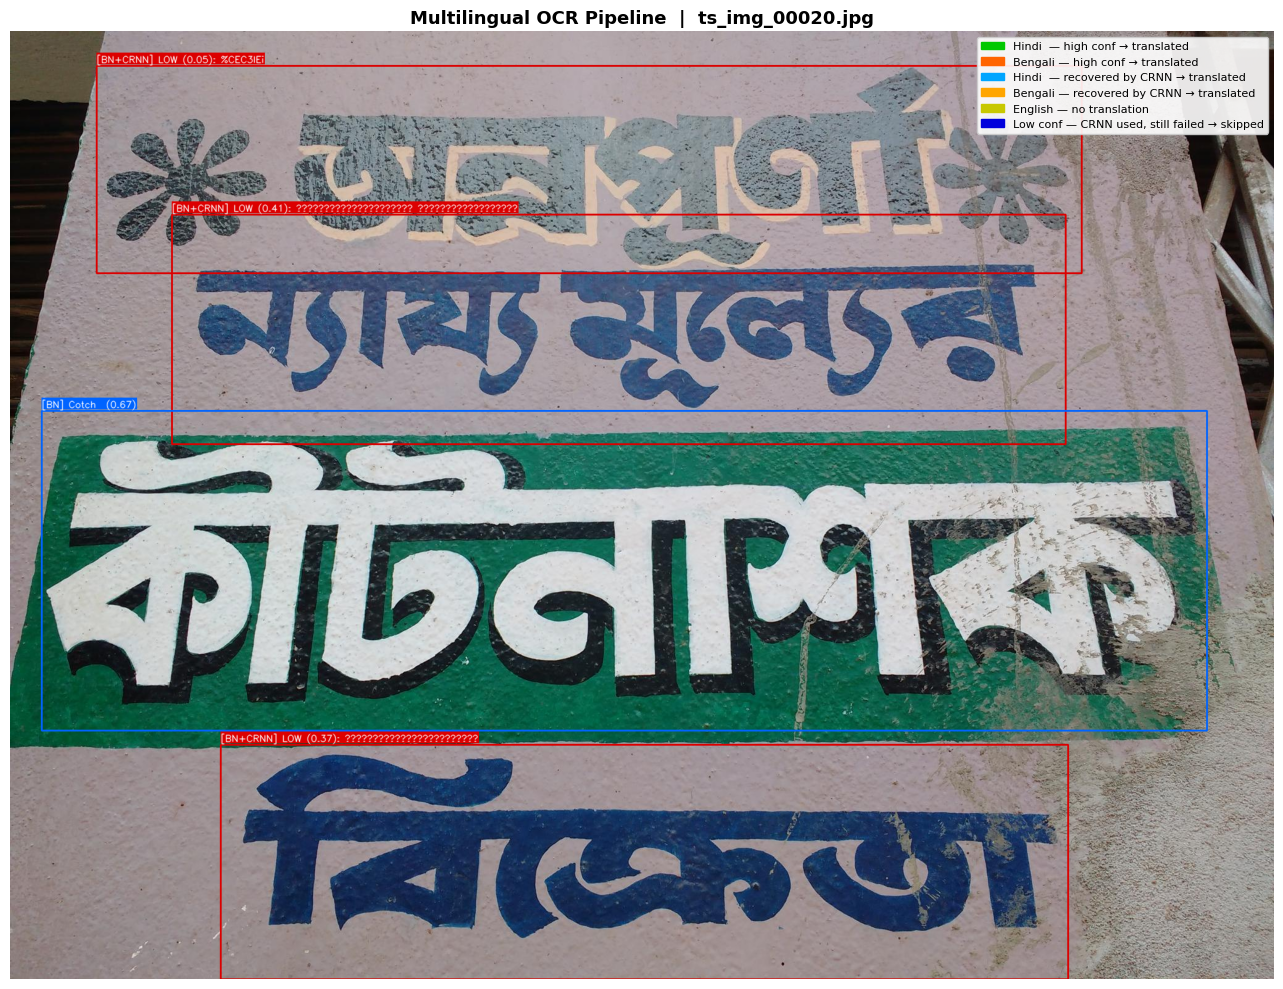


────────────────────────────────────────────────────────────────────────────────
  #      Lang   Conf  CRNN  OCR Text                Translation
────────────────────────────────────────────────────────────────────────────────
  0        BN   0.05   YES  %CEC3IEi                — (low confidence)
  1        BN   0.41   YES  ন্যায্য মূল্যর          — (low confidence)
  2        BN   0.67    no  কটনাশক                  Cotch
  3        BN   0.37   YES  নিঙ্েত্া                — (low confidence)
────────────────────────────────────────────────────────────────────────────────
Total: 4 regions | CRNN invoked on: 3 low-confidence regions


In [92]:
image_path = "/kaggle/input/datasets/divyanshueopal/tistii/ts_img_00020.jpg"
draw_boxes(image_path)